# Style response diagnostic: requested vs. achieved

For each of the 6 style axes we set that axis of the conditioning vector to a
range of **requested** values (-2σ … +2σ), decode the *same* content codes, then
run the decoded output back through the **same `StyleMeasurer`** the model was
trained against to read the **achieved** style value.

Plotting requested (x) vs achieved (y) gives, per axis, a curve whose **slope**
is the control gain:

* slope ≈ 1  → the knob works (output tracks the request),
* slope ≈ 0 & flat everywhere → the knob is ignored / the model can't represent it,
* positive near 0 but flattening at the extremes → control exists but **saturates**.

No video rendering — this runs in seconds.

In [1]:
from pathlib import Path
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Resolve project root robustly whether launched from repo root or main/.
cwd = Path.cwd()
if (cwd / 'config').exists():
    project_root = cwd
elif (cwd.parent / 'config').exists():
    project_root = cwd.parent
elif Path('/mnt/fastertalk/config').exists():
    project_root = Path('/mnt/fastertalk')
else:
    raise RuntimeError('Could not locate project root containing config/.')

os.chdir(project_root)
print('Project root:', Path.cwd())

from utils.config import load_flat_config
from models import get_model
from dataset.data_loader_joint_data_batched import get_dataloaders
from dataset.style_measure import StyleMeasurer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Project root: /mnt/fastertalk
Device: cuda


In [2]:
# --- Config, checkpoint, style axes ---
cfg = load_flat_config('config/talkinghead-1kh/stage1_style.yaml')
cfg.batch_size = 1
cfg.save_path = '/mnt/fastertalk/logs/stage1_style/checkpoints/epoch_300.pt'

STYLE_NAMES = ['lips_disp', 'lips_speed', 'forehead_disp', 'forehead_speed', 'eyes_disp', 'eyes_speed']
N_STYLE = len(STYLE_NAMES)

# Requested style values to probe along each axis (in z-scored σ units).
REQUESTED = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float32)

print('Checkpoint:', cfg.save_path)
print('Style axes:', STYLE_NAMES)
print('Requested values:', REQUESTED.tolist())

Checkpoint: /mnt/fastertalk/logs/stage1_style/checkpoints/epoch_300.pt
Style axes: ['lips_disp', 'lips_speed', 'forehead_disp', 'forehead_speed', 'eyes_disp', 'eyes_speed']
Requested values: [-2.0, -1.0, 0.0, 1.0, 2.0]


In [3]:
# --- Load model, StyleMeasurer, and test data ---
dls = get_dataloaders(cfg)
test_loader = dls['test']

def _resolve_checkpoint(path_cfg):
    path_cfg = Path(path_cfg)
    if path_cfg.is_file():
        return path_cfg
    if path_cfg.is_dir():
        ckpts = sorted(path_cfg.glob('epoch_*.pt'))
        return ckpts[-1] if ckpts else None
    return None

ckpt_file = _resolve_checkpoint(cfg.save_path)
model = get_model(cfg).to(device)
if ckpt_file is not None:
    ckpt = torch.load(ckpt_file, map_location=device)
    state_dict = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print('Loaded checkpoint:', ckpt_file)
    print('Missing keys:', len(missing), '| Unexpected keys:', len(unexpected))
else:
    print('No valid checkpoint found - using random weights.')
model.eval()

stats_path = Path(cfg.data_root) / 'annotations' / 'style_disp_stats.npz'
measurer = StyleMeasurer(stats_path).to(device)
measurer.eval()
print('StyleMeasurer ready. stats:', stats_path)

Loading data...
Data root: /mnt/Datasets/ARTalk_data
Audio path: /mnt/Datasets/ARTalk_data/wav
Vertices path: /mnt/Datasets/ARTalk_data/npz
Annotations root: /mnt/Datasets/ARTalk_data/annotations
Style disp stats loaded (z-score normalization enabled).
Train lines read: 5589
Test lines read: 621


100%|██████████| 6210/6210 [00:07<00:00, 854.88it/s]


Style sidecar missing/mismatched for 0 files.
Total sequences: 9428  Non-existent files: 0
Train matches (basename): 5589 Test matches (basename): 621
Loaded data: Train-7636, Val-896, Test-896
Total hours of data: 44.76
Data augmentation enabled for training (input-only corruption).
Loaded checkpoint: /mnt/fastertalk/logs/stage1_style/checkpoints/epoch_300.pt
Missing keys: 0 | Unexpected keys: 0
StyleMeasurer ready. stats: /mnt/Datasets/ARTalk_data/annotations/style_disp_stats.npz


In [4]:
# --- Collect a fixed set of test clips to average the response over ---
NUM_CLIPS = 8

clips = []
for i, batch in enumerate(test_loader):
    if i >= NUM_CLIPS:
        break
    blendshapes_in, blendshapes_tgt, mask, style = batch
    clips.append((blendshapes_in.to(device), mask.to(device)))
print(f'Collected {len(clips)} test clips.')

Collected 8 test clips.


In [5]:
# --- Core sweep: for each axis and each requested value, decode and measure ---
# achieved[axis, value, clip] = measured value of that axis after decoding with
# the conditioning vector set to `value` on `axis` (all other axes = 0).

@torch.no_grad()
def measure_response(model, measurer, clips):
    n_vals = len(REQUESTED)
    # achieved[axis, value] averaged over clips
    achieved = np.zeros((N_STYLE, n_vals), dtype=np.float32)

    for blendshapes_in, mask in clips:
        # Encode content once per clip (codes are shared across all style settings).
        quantized, _ = model.get_quant(blendshapes_in, mask)

        for axis in range(N_STYLE):
            for vi, val in enumerate(REQUESTED):
                style_vec = torch.zeros(1, N_STYLE, device=device)
                style_vec[0, axis] = float(val)
                pred = model.decode(quantized, mask, style=style_vec)   # [1, T, 58]
                meas = measurer(pred, mask)                             # [1, 6]
                achieved[axis, vi] += float(meas[0, axis].item())

    achieved /= len(clips)
    return achieved

achieved = measure_response(model, measurer, clips)
print('achieved shape:', achieved.shape, '(axis, value)')

achieved shape: (6, 5) (axis, value)


In [6]:
# --- Per-axis slope (control gain) via least-squares fit of achieved vs requested ---
def slope_intercept(x, y):
    A = np.vstack([x, np.ones_like(x)]).T
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, b

print(f"{'axis':<16} {'slope':>8} {'achieved @ -2..+2'}")
print('-' * 60)
slopes = {}
for axis, name in enumerate(STYLE_NAMES):
    m, b = slope_intercept(REQUESTED, achieved[axis])
    slopes[name] = m
    vals = '  '.join(f'{v:+.2f}' for v in achieved[axis])
    print(f'{name:<16} {m:>8.3f}   [{vals}]')

axis                slope achieved @ -2..+2
------------------------------------------------------------
lips_disp           0.853   [-1.27  -0.76  +0.10  +1.09  +2.08]
lips_speed          0.901   [-1.56  -0.73  +0.29  +1.20  +1.98]
forehead_disp       0.920   [-1.62  -0.94  +0.06  +1.03  +1.99]
forehead_speed      0.836   [-1.33  -0.90  +0.02  +0.99  +1.90]
eyes_disp           0.985   [-1.74  -1.06  -0.03  +1.08  +2.12]
eyes_speed          0.723   [-0.48  -0.88  +0.01  +1.13  +2.13]


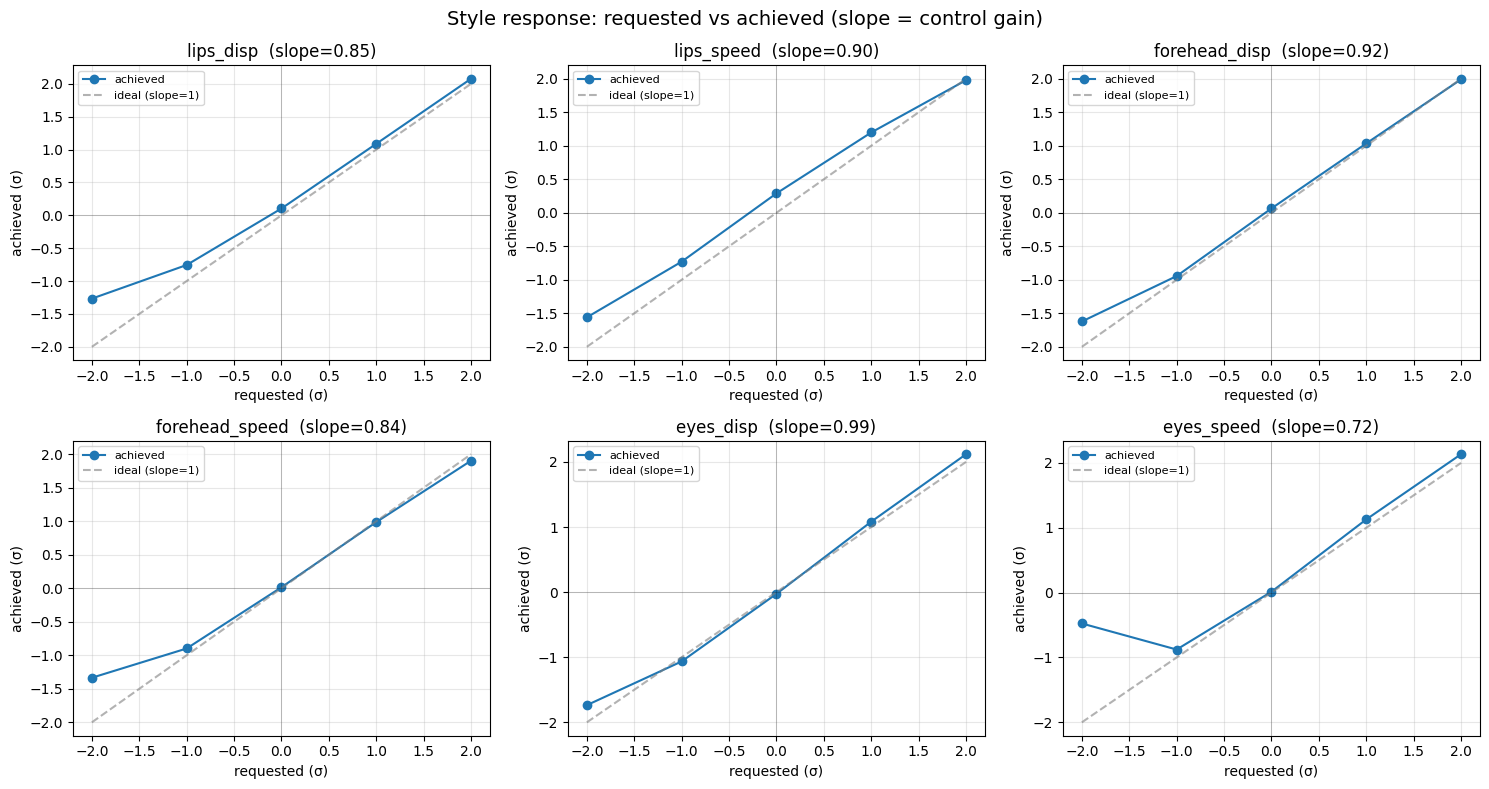

In [7]:
# --- Plot requested vs achieved for all 6 axes ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, (ax, name) in enumerate(zip(axes.flat, STYLE_NAMES)):
    ax.plot(REQUESTED, achieved[axis], 'o-', label='achieved')
    ax.plot(REQUESTED, REQUESTED, '--', color='gray', alpha=0.6, label='ideal (slope=1)')
    ax.set_title(f'{name}  (slope={slopes[name]:.2f})')
    ax.set_xlabel('requested (σ)')
    ax.set_ylabel('achieved (σ)')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Style response: requested vs achieved (slope = control gain)', fontsize=14)
fig.tight_layout()
plt.show()

## How to read the results

* **slope ≈ 1, points on the dashed line** — the knob works (expect this for `lips_*`).
* **slope ≈ 0, flat line across all requested values** — the knob is ignored *and*
  the model cannot represent the change → measurement / leverage problem.
* **positive slope near 0 but the curve flattens at ±2σ** — control exists but
  **saturates** → code-preservation pinning or out-of-distribution extremes.

The flat vs. plateau distinction looks identical in a rendered video but points to
opposite fixes. To test the saturation hypothesis directly, retrain with a lower
`code_preservation_weight` (e.g. 0.02) and rerun this notebook: if the
forehead/eye slopes rise, code-preservation was the bottleneck.